# SETUP

In [2]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from packaging import version
import sklearn

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

assert sys.version_info >= (3, 8)
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

np.random.seed(42)
warnings.filterwarnings("ignore")

plt.rc("font", size=14)
plt.rc("axes", labelsize=14, titlesize=14)
plt.rc("legend", fontsize=12)
plt.rc("xtick", labelsize=10)
plt.rc("ytick", labelsize=10)
sns.set_style("whitegrid")

IMAGES_PATH = Path("images/classification_project")
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution, bbox_inches="tight")

# Projeto Final de Aprendizado de Máquina

## 5.1 Identificação e descrição do problema

### Título
Previsão do tipo de assinatura de usuários em uma plataforma de streaming musical.

### Integrantes
- Artur Gabriel Dantas Santos.
- Kaíque Teixeira Rodrigues.
- Matheus Mendonca Santana.

### Fonte dos dados
Conjunto de dados **Music Streaming Habits 2026**, disponível publicamente no Kaggle.

### Objetivo
Desenvolver um modelo de aprendizado de máquina capaz de prever o tipo de assinatura de um usuário com base em seus hábitos de consumo musical.

### Atributo-alvo
O atributo-alvo definido para este projeto é **`subscription`**, que representa o tipo de assinatura do usuário, com as classes:
- Free
- Premium
- Family
- Student

### Atributos preditivos
Os atributos utilizados como variáveis preditoras são:
- `age`
- `country`
- `platform`
- `top_genre`
- `top_artist`
- `daily_listening_minutes`
- `songs_per_day`
- `playlists_count`
- `skip_rate_pct`
- `discover_weekly_user`
- `top_mood`
- `uses_offline_mode`
- `podcasts_too`

O atributo `listener_id` não será utilizado na modelagem, pois funciona apenas como identificador do registro.

### Tipo da tarefa
O problema foi formulado como uma tarefa de **classificação multiclasse**, pois o atributo-alvo `subscription` possui mais de uma categoria possível e não representa um valor numérico contínuo.

## 5.2 Compreensão dos dados

###Importando o DataSet

In [3]:
import os
import pandas as pd
import kagglehub

dataset_path = kagglehub.dataset_download("uditjain13/music-streaming-habits-2026")
csv_files = [f for f in os.listdir(dataset_path) if f.endswith(".csv")]

if not csv_files:
    raise FileNotFoundError("Nenhum CSV encontrado no dataset.")

df = pd.read_csv(os.path.join(dataset_path, csv_files[0]))
print(df.head())

Using Colab cache for faster access to the 'music-streaming-habits-2026' dataset.
   listener_id  age    country      platform subscription  top_genre  \
0            1   24  Australia   Apple Music         Free        R&B   
1            2   21    Germany       Spotify         Free  Classical   
2            3   32      Japan  Amazon Music         Free    Hip-Hop   
3            4   39      Japan   Apple Music         Free        Pop   
4            5   23      India       Spotify       Family    Country   

       top_artist  daily_listening_minutes  songs_per_day  playlists_count  \
0  Kendrick Lamar                      191             54                9   
1           Drake                      249             68               10   
2  Olivia Rodrigo                       49             11               11   
3       Burna Boy                       96             22                8   
4  Olivia Rodrigo                      100             24               13   

   skip_rate_pct

### Preparação

In [4]:
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

target = "subscription"

num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Variáveis numéricas:", num_cols)
print("\nVariáveis categóricas:", cat_cols)

Variáveis numéricas: ['listener_id', 'age', 'daily_listening_minutes', 'songs_per_day', 'playlists_count', 'skip_rate_pct']

Variáveis categóricas: ['country', 'platform', 'subscription', 'top_genre', 'top_artist', 'top_mood']


In [5]:
display(df.head())

print("Dimensões do conjunto:", df.shape)
print("\nTipos de dados:")
display(df.dtypes)

print("\nValores ausentes por coluna:")
display(df.isna().sum().sort_values(ascending=False))

print("\nResumo estatístico:")
display(df.describe(include="all").T)

,listener_id,age,country,platform,subscription,top_genre,top_artist,daily_listening_minutes,songs_per_day,playlists_count,skip_rate_pct,discover_weekly_user,top_mood,uses_offline_mode,podcasts_too
0,1,24,Australia,Apple Music,Free,R&B,Kendrick Lamar,191,54,9,39.30,False,Sleep,False,True
1,2,21,Germany,Spotify,Free,Classical,Drake,249,68,10,18.30,True,Workout,True,True
2,3,32,Japan,Amazon Music,Free,Hip-Hop,Olivia Rodrigo,49,11,11,22.70,True,Sad,False,True
3,4,39,Japan,Apple Music,Free,Pop,Burna Boy,96,22,8,29.40,True,Sad,True,False
4,5,23,India,Spotify,Family,Country,Olivia Rodrigo,100,24,13,37.70,True,Workout,True,True


Dimensões do conjunto: (4000, 15)

Tipos de dados:


,0
listener_id,int64
age,int64
country,object
platform,object
subscription,object
top_genre,object
top_artist,object
daily_listening_minutes,int64
songs_per_day,int64
playlists_count,int64



Valores ausentes por coluna:


,0
listener_id,0
age,0
country,0
platform,0
subscription,0
top_genre,0
top_artist,0
daily_listening_minutes,0
songs_per_day,0
playlists_count,0



Resumo estatístico:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
listener_id,"4,000.00",NaN,NaN,NaN,"2,000.50","1,154.84",1.00,"1,000.75","2,000.50","3,000.25","4,000.00"
age,"4,000.00",NaN,NaN,NaN,27.85,8.60,13.00,22.00,28.00,34.00,57.00
country,4000,10,Japan,439,NaN,NaN,NaN,NaN,NaN,NaN,NaN
platform,4000,6,Spotify,1591,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subscription,4000,4,Free,1820,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top_genre,4000,12,Pop,721,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top_artist,4000,14,SZA,310,NaN,NaN,NaN,NaN,NaN,NaN,NaN
daily_listening_minutes,"4,000.00",NaN,NaN,NaN,138.70,86.30,5.00,74.00,122.00,185.00,697.00
songs_per_day,"4,000.00",NaN,NaN,NaN,39.14,25.05,1.00,21.00,35.00,52.25,198.00
playlists_count,"4,000.00",NaN,NaN,NaN,8.99,3.03,1.00,7.00,9.00,11.00,22.00




Nesta etapa, foi feita uma leitura inicial do conjunto de dados para entender sua estrutura, qualidade e possíveis necessidades de tratamento antes da modelagem.

### Quantidade de registros e atributos
O conjunto de dados possui **4000 registros** e **15 colunas**. A coluna `listener_id` funciona apenas como identificador e não será usada como variável preditiva, então o problema será modelado com **14 atributos úteis**.

### Tipos das variáveis
O dataset contém variáveis numéricas, categóricas e booleanas. As colunas numéricas são `age`, `daily_listening_minutes`, `songs_per_day`, `playlists_count` e `skip_rate_pct`. As colunas categóricas são `country`, `platform`, `subscription`, `top_genre`, `top_artist` e `top_mood`. As colunas booleanas são `discover_weekly_user`, `uses_offline_mode` e `podcasts_too`.

### Valores ausentes
A verificação de valores ausentes mostrou **0 valores nulos no total**. Isso indica que não será necessário imputar valores ausentes nesta base.

### Duplicações
Foram encontrados **0 registros duplicados**. Não há duplicações relevantes, então os dados podem seguir para a análise e modelagem.

### Inconsistências
Em uma verificação inicial, não foram observadas inconsistências óbvias nas colunas principais, como valores incompatíveis com o tipo esperado ou categorias fora do padrão. Ainda assim, essa etapa deve ser complementada com análises específicas nas variáveis categóricas e na faixa de valores das variáveis numéricas.

### Distribuição do atributo-alvo
A variável-alvo `subscription` apresenta a seguinte distribuição:
- **Free**: 1820 registros (45.5%)
- **Student**: 401 registros (10.02%)
- **Premium**: 1193 registros (29.83%)
- **Family**: 596 registros (14.65%)

### Desbalanceamento
Há sinais de desbalanceamento moderado entre as classes. Como o problema é de classificação multiclasse, essa distribuição precisa ser considerada na divisão treino/teste e na escolha das métricas de avaliação. A acurácia sozinha não deve ser usada como única referência de desempenho; por isso, também serão observados matriz de confusão, precisão, revocação e F1-score.

## 5.3 Análise exploratória

Nesta seção, é apresentada uma análise exploratória do conjunto de dados de hábitos de streaming musical. O objetivo é compreender a distribuição dos atributos, identificar padrões, verificar possíveis relações entre variáveis e analisar como esses atributos se relacionam com a variável-alvo `subscription`.


### Visão geral do conjunto de dados

Inicialmente, foram verificadas as dimensões do conjunto, os tipos das variáveis e a presença de valores ausentes. Essa etapa é importante para entender a estrutura dos dados e orientar as análises seguintes.

### Distribuição da variável-alvo

A seguir, analisa-se a distribuição das categorias da variável `subscription`, a fim de verificar se há equilíbrio entre as classes.

In [6]:
freq_target = df[target].value_counts(dropna=False).rename_axis(target).reset_index(name="frequencia")
freq_target["percentual"] = (freq_target["frequencia"] / len(df) * 100).round(2)
display(freq_target)

,subscription,frequencia,percentual
0,Free,1820,45.50
1,Premium,1193,29.83
2,Family,586,14.65
3,Student,401,10.02


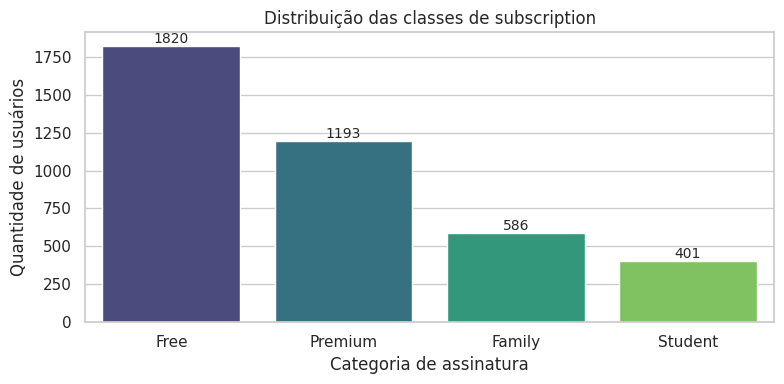

In [7]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df, x=target, order=df[target].value_counts().index, palette="viridis")
plt.title("Distribuição das classes de subscription")
plt.xlabel("Categoria de assinatura")
plt.ylabel("Quantidade de usuários")

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

**Comentário:**  
A tabela e o gráfico permitem verificar se as classes de assinatura estão balanceadas. E como comentado anteriormente na seção 5.2 podemos ver um desbalanceamento entre as categorias

### Tabelas de frequência para atributos categóricos

Como o conjunto possui atributos categóricos relacionados ao comportamento musical, foram construídas tabelas de frequência para examinar a distribuição dessas categorias entre os usuários.

In [8]:
for col in cat_cols:
    print(f"\n### Frequência de: {col}")
    freq = df[col].value_counts(dropna=False).reset_index()
    freq.columns = [col, "frequencia"]
    freq["percentual"] = (freq["frequencia"] / len(df) * 100).round(2)
    display(freq.head(10))


### Frequência de: country


,country,frequencia,percentual
0,Japan,439,10.98
1,Canada,429,10.72
2,USA,418,10.45
3,Brazil,409,10.22
4,Nigeria,401,10.02
5,Australia,397,9.93
6,India,390,9.75
7,France,377,9.43
8,Germany,371,9.28
9,UK,369,9.22



### Frequência de: platform


,platform,frequencia,percentual
0,Spotify,1591,39.78
1,Apple Music,906,22.65
2,YouTube Music,689,17.22
3,Amazon Music,315,7.88
4,SoundCloud,278,6.95
5,Tidal,221,5.52



### Frequência de: subscription


...

,top_genre,frequencia,percentual
0,Pop,721,18.02
1,Hip-Hop,605,15.12
2,Rock,472,11.80
3,EDM,382,9.55
4,R&B,341,8.52
5,Indie,327,8.18
6,K-Pop,278,6.95
7,Afrobeats,210,5.25
8,Lo-fi,201,5.03
9,Classical,166,4.15



### Frequência de: top_artist


,top_artist,frequencia,percentual
0,SZA,310,7.75
1,Bad Bunny,305,7.62
2,The Weeknd,302,7.55
3,Dua Lipa,298,7.45
4,Taylor Swift,294,7.35
5,Travis Scott,293,7.32
6,Olivia Rodrigo,290,7.25
7,Tyler the Creator,287,7.18
8,Drake,285,7.12
9,Burna Boy,285,7.12



### Frequência de: top_mood


,top_mood,frequencia,percentual
0,Sad,538,13.45
1,Chill,529,13.23
2,Happy,515,12.88
3,Workout,499,12.48
4,Energetic,492,12.30
5,Sleep,477,11.92
6,Party,476,11.90
7,Focus,474,11.85


**Comentário:**  
As tabelas de frequência permitem identificar categorias mais comuns, como plataforma de streaming, gênero favorito ou período de escuta. Essas variáveis podem ter relação direta com o tipo de assinatura adotado pelo usuário.

### Medidas de localidade e dispersão

Para os atributos numéricos, foram calculadas medidas descritivas com o objetivo de resumir tendência central e variabilidade.

In [9]:
stats = pd.DataFrame({
    "media": df[num_cols].mean(),
    "mediana": df[num_cols].median(),
    "desvio_padrao": df[num_cols].std(),
    "variancia": df[num_cols].var(),
    "minimo": df[num_cols].min(),
    "maximo": df[num_cols].max()
})

display(stats.sort_values("desvio_padrao", ascending=False))

,media,mediana,desvio_padrao,variancia,minimo,maximo
listener_id,"2,000.50","2,000.50","1,154.84","1,333,666.67",1.00,"4,000.00"
daily_listening_minutes,138.70,122.00,86.30,"7,447.00",5.00,697.00
songs_per_day,39.14,35.00,25.05,627.32,1.00,198.00
skip_rate_pct,28.16,28.10,11.82,139.61,0.00,70.90
age,27.85,28.00,8.60,73.89,13.00,57.00
playlists_count,8.99,9.00,3.03,9.17,1.00,22.00


**Comentário:**  
Essas medidas ajudam a verificar o comportamento dos atributos quantitativos, como tempo diário de escuta, quantidade de músicas ou taxa de pulo. Diferenças relevantes entre média e mediana podem indicar assimetria, enquanto desvio padrão elevado sugere maior heterogeneidade entre os usuários.

### Histogramas das variáveis numéricas

Os histogramas foram utilizados para analisar o formato da distribuição das variáveis quantitativas.

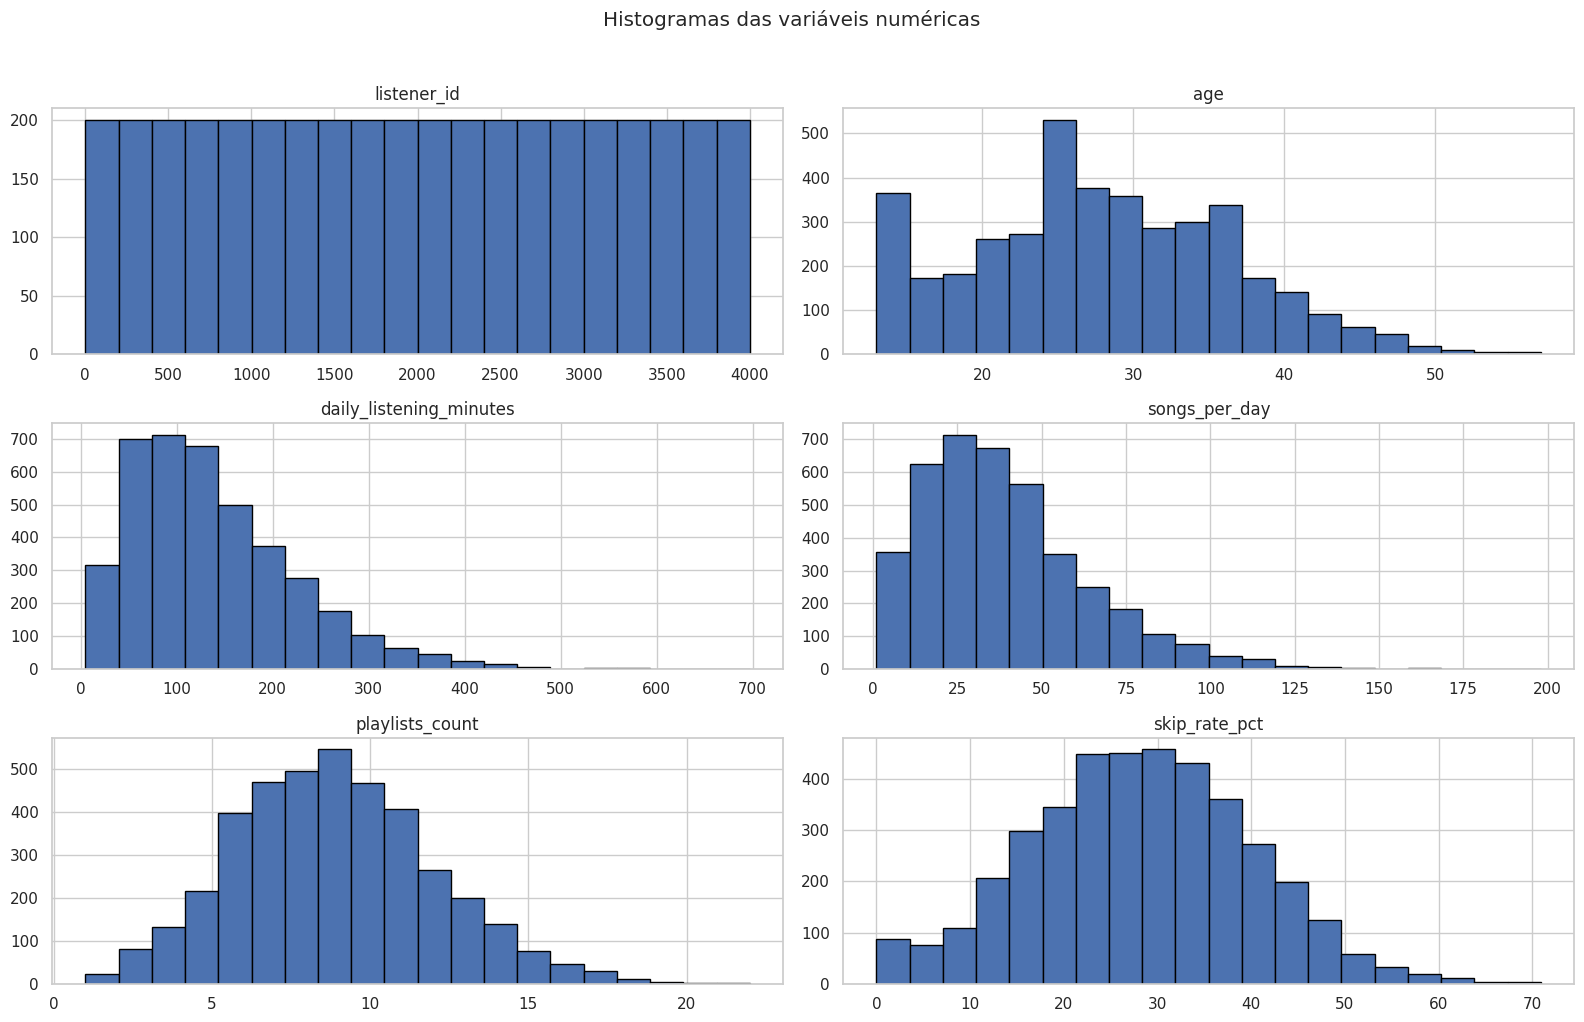

In [10]:
df[num_cols].hist(figsize=(16, 10), bins=20, edgecolor="black")
plt.suptitle("Histogramas das variáveis numéricas", y=1.02)
plt.tight_layout()
plt.show()

**Comentário:**  
Os histogramas mostram se as distribuições são aproximadamente simétricas, concentradas em certas faixas ou marcadas por caudas longas. Essa análise é útil para detectar atributos com comportamento muito concentrado ou com grande dispersão e podemos observar que os dados sao até que bem concentrados.

### Correlação entre variáveis numéricas

A matriz de correlação foi utilizada para investigar relações lineares entre os atributos quantitativos.

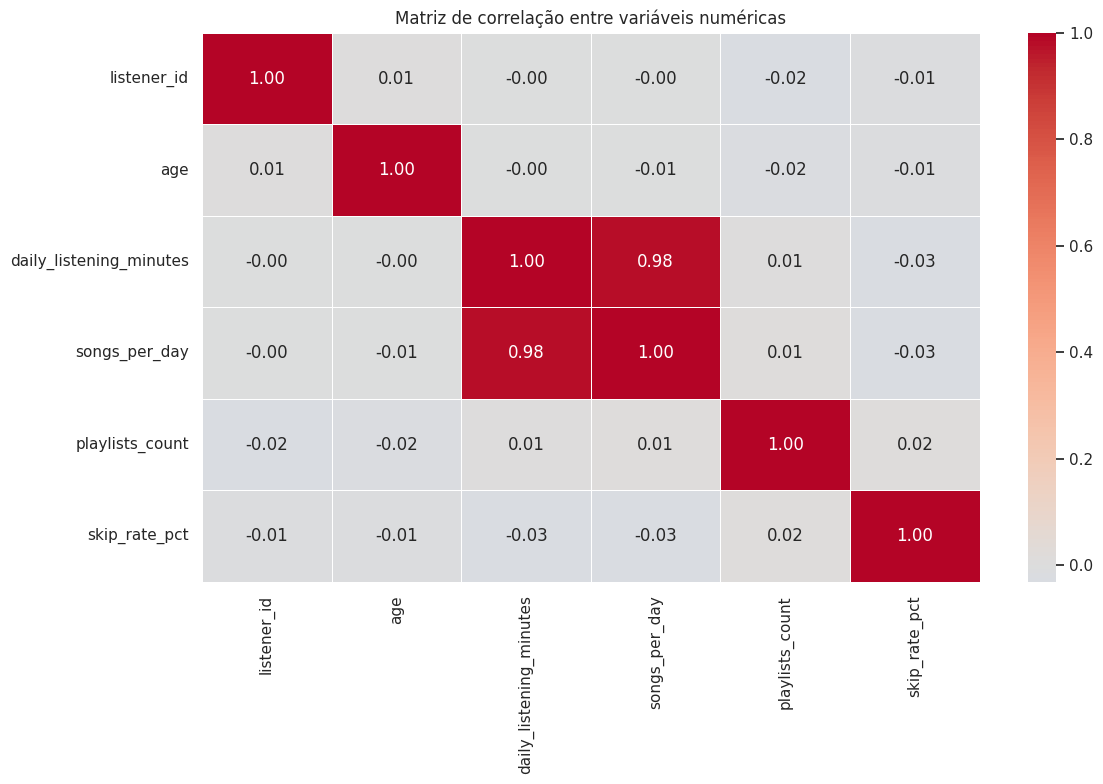

In [11]:
corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Matriz de correlação entre variáveis numéricas")
plt.tight_layout()
plt.show()

**Comentário:**  
A matriz de correlação ajuda a identificar pares de variáveis que variam de forma semelhante. No contexto deste dataset é possivel observar a correlação entre minutos e quantidade de músicas.

### Relação entre atributos e a variável-alvo

Nesta etapa, são observadas as relações entre os atributos e a variável `subscription`, buscando identificar variáveis com maior potencial preditivo.

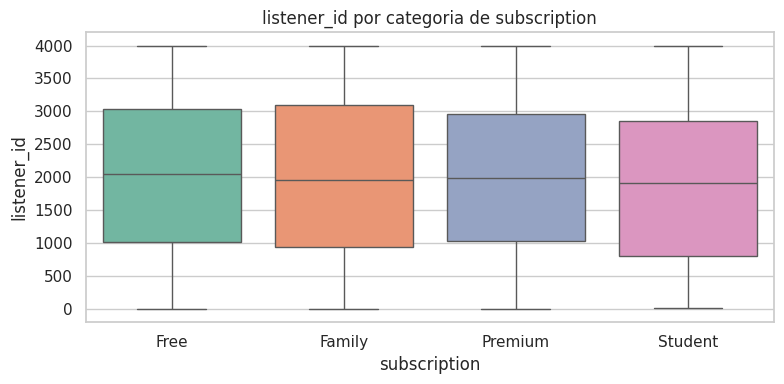

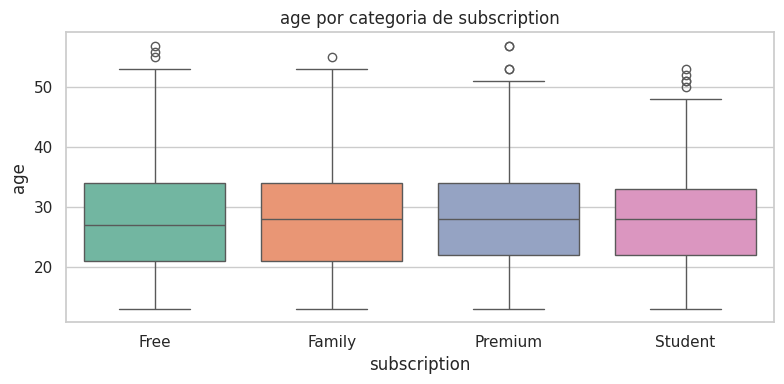

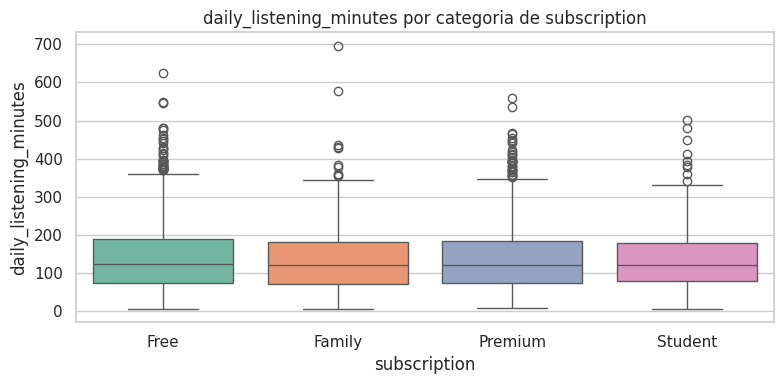

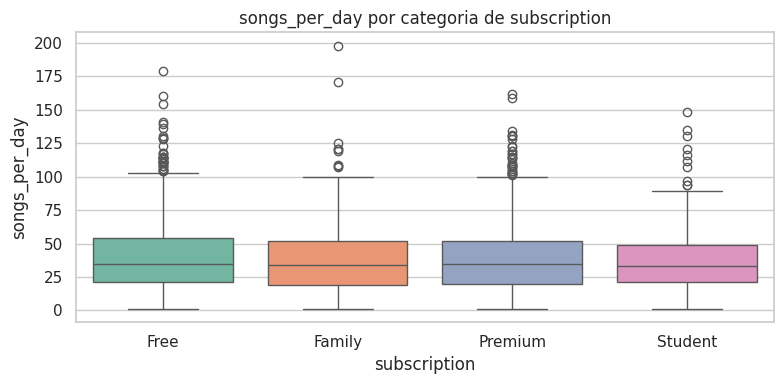

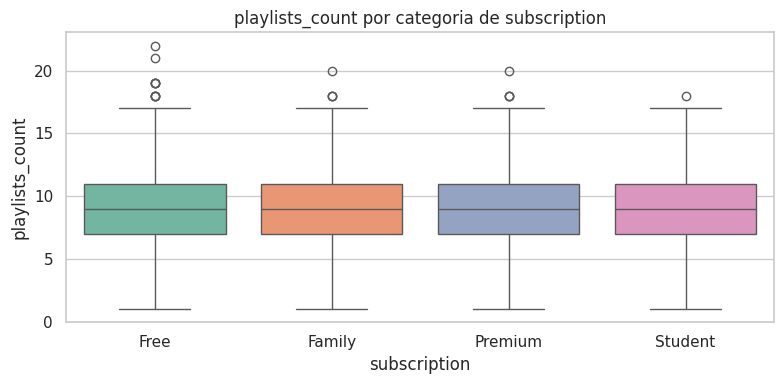

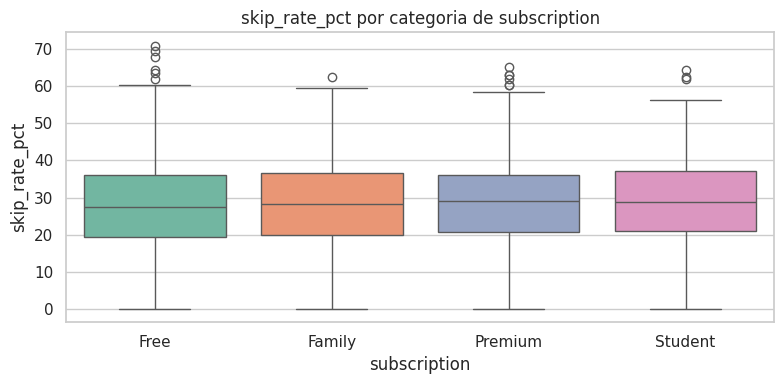

In [12]:
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=target, y=col, palette="Set2")
    plt.title(f"{col} por categoria de subscription")
    plt.xlabel("subscription")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

**Comentário:**  
Esses gráficos permitem verificar se usuários de diferentes tipos de assinatura apresentam comportamentos distintos. Caso certas classes apresentem medianas ou distribuições claramente diferentes, o atributo pode ser relevante para a classificação. Como podemos observar os pontos não apresentão um padrão tão definido por classe, algo que vai influenciar negativamente na análise e veremos isso no final.

### Relação entre variáveis categóricas e a variável-alvo

Também foram analisadas tabelas cruzadas entre atributos categóricos e o alvo, a fim de identificar associações entre preferências musicais e tipo de assinatura.

In [13]:
for col in cat_cols:
    if col == target:
        continue

    print(f"\n### Tabela cruzada: {col} x {target}")
    tabela = pd.crosstab(df[col], df[target], normalize="index") * 100
    display(tabela.round(2))


### Tabela cruzada: country x subscription


subscription,Family,Free,Premium,Student
country,,,,
Australia,18.39,44.58,28.21,8.82
Brazil,14.67,42.79,32.52,10.02
Canada,13.05,46.39,28.67,11.89
France,14.32,46.68,29.44,9.55
Germany,13.48,45.55,28.30,12.67
India,11.79,50.00,30.51,7.69
Japan,16.63,48.52,25.51,9.34
Nigeria,15.21,45.39,29.18,10.22
UK,14.63,43.63,31.17,10.57



### Tabela cruzada: platform x subscription


subscription,Family,Free,Premium,Student
platform,,,,
Amazon Music,13.97,51.43,25.71,8.89
Apple Music,15.12,45.25,30.79,8.83
SoundCloud,14.75,47.12,31.29,6.83
Spotify,14.46,44.63,29.73,11.19
Tidal,16.74,42.53,30.77,9.95
YouTube Music,14.08,45.43,29.75,10.74



### Tabela cruzada: top_genre x subscription


subscription,Family,Free,Premium,Student
top_genre,,,,
Afrobeats,14.29,47.14,29.52,9.05
Classical,15.66,42.77,31.33,10.24
Country,17.58,39.39,33.33,9.70
EDM,14.66,41.36,32.20,11.78
Hip-Hop,15.70,45.12,29.09,10.08
Indie,11.62,43.73,31.80,12.84
Jazz,12.88,54.55,23.48,9.09
K-Pop,14.03,46.76,30.22,8.99
Lo-fi,14.93,43.28,29.35,12.44



### Tabela cruzada: top_artist x subscription


subscription,Family,Free,Premium,Student
top_artist,,,,
Ariana Grande,15.98,41.39,32.38,10.25
BTS,12.31,48.51,23.51,15.67
Bad Bunny,13.77,45.90,30.82,9.51
Billie Eilish,15.04,45.11,31.58,8.27
Burna Boy,14.39,47.72,26.32,11.58
Drake,13.33,43.51,29.82,13.33
Dua Lipa,17.11,43.96,30.20,8.72
Kendrick Lamar,15.02,46.52,30.77,7.69
Olivia Rodrigo,14.14,48.28,27.24,10.34



### Tabela cruzada: top_mood x subscription


subscription,Family,Free,Premium,Student
top_mood,,,,
Chill,13.80,46.69,29.49,10.02
Energetic,16.06,42.48,31.91,9.55
Focus,16.03,43.25,30.80,9.92
Happy,16.50,47.96,24.47,11.07
Party,10.50,45.38,33.61,10.50
Sad,13.20,49.44,27.70,9.67
Sleep,15.93,42.35,32.08,9.64
Workout,15.23,45.69,29.26,9.82


**Comentário:**  
As tabelas cruzadas mostram como as categorias de cada atributo se distribuem entre os tipos de assinatura. Essa análise é útil para verificar, por exemplo, se determinadas plataformas, estilos musicais ou padrões de uso aparecem com maior frequência em classes específicas. E novamente vemos que as categorias são bem distruibuidas entre si

### Gráficos de dispersão

Os gráficos de dispersão foram utilizados para observar relações entre pares de variáveis numéricas e verificar se existe separação visual entre as classes da variável-alvo.

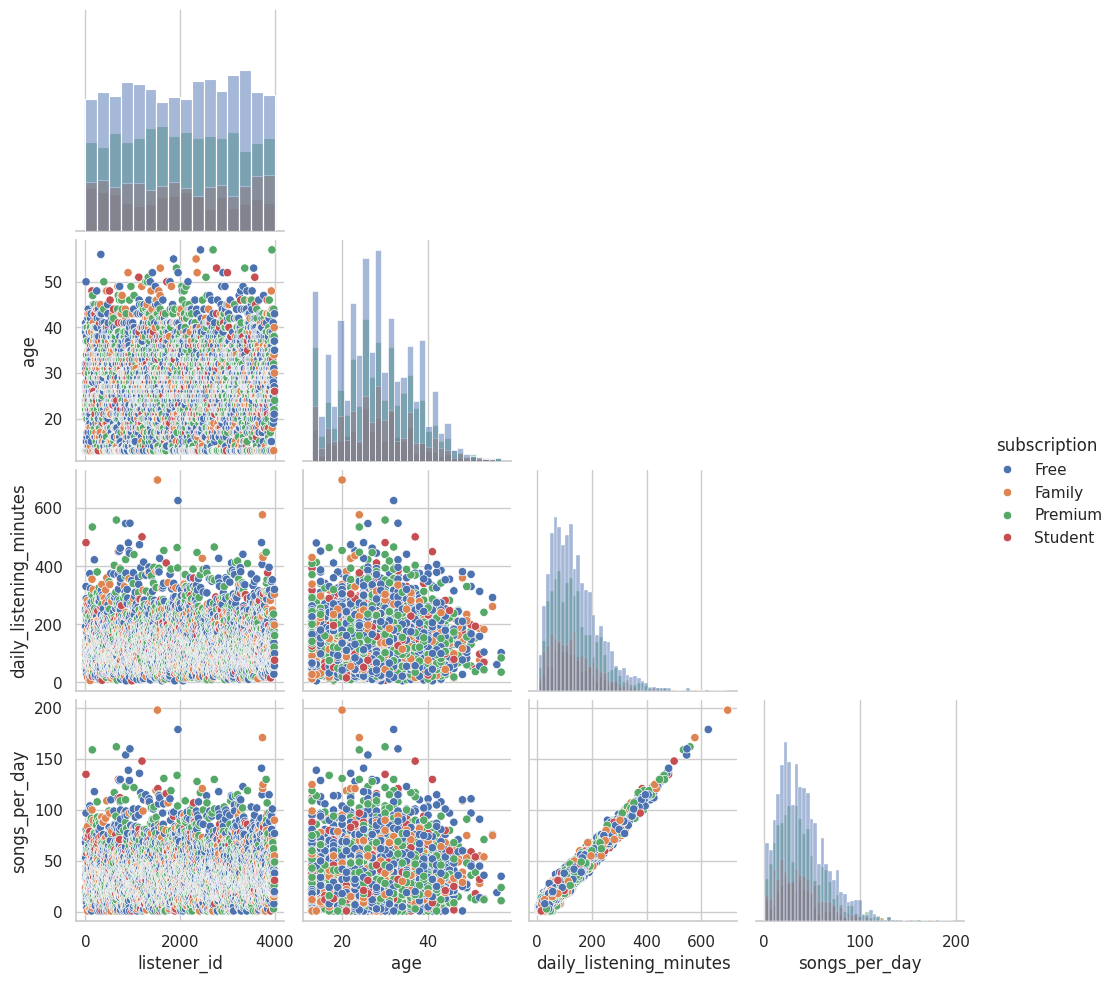

In [14]:
if target in num_cols:
    rel_cols = corr[target].abs().sort_values(ascending=False).head(5).index.tolist()
    rel_cols = [c for c in rel_cols if c != target]
else:
    rel_cols = num_cols[:4]

pairplot_cols = rel_cols[:4] + [target]
sns.pairplot(df[pairplot_cols], hue=target, corner=True, diag_kind="hist")
plt.show()

**Comentário:**  
Os gráficos de dispersão permitem observar padrões de agrupamento e sobreposição entre classes. Quando existe alguma separação visual entre categorias de `subscription`, isso sugere que os atributos utilizados podem contribuir para a construção de um classificador.

### Síntese da análise exploratória

A análise exploratória permitiu compreender a distribuição dos atributos, a presença de possíveis valores extremos e as associações entre variáveis e a classe-alvo. Essas observações servem como base para as etapas seguintes de pré-processamento, seleção de atributos e construção dos modelos de classificação.

## 5.4 e 5.5 Pré-processamento e Separação dos dados

Nesta etapa, foram realizados os tratamentos necessários para preparar os dados para a modelagem. Os problemas identificados, as decisões adotadas e as justificativas de cada tratamento são apresentados a seguir. A análise exploratória da seção 5.3 já mostrou o comportamento geral das variáveis; aqui o foco está no refinamento dos dados para uso em treinamento e teste.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

target = "subscription"

X = df.drop(columns=[target]).copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

X_train: (3000, 14)
X_test: (1000, 14)


In [16]:
class_distribution = y_train.value_counts()
class_percentage = (class_distribution / len(y_train) * 100).round(2)

display(
    pd.DataFrame({
        "frequencia": class_distribution,
        "percentual": class_percentage
    })
)

,frequencia,percentual
subscription,,
Free,1365,45.50
Premium,895,29.83
Family,439,14.63
Student,301,10.03


**Comentário:**  
As variáveis numéricas serão tratadas com imputação pela mediana e escalonamento, enquanto as variáveis categóricas serão tratadas com imputação pela moda e codificação one-hot.
A divisão entre treino e teste foi feita antes do ajuste das transformações para evitar vazamento de informações e a proporção escolhida foi a surgerida em aula.  
A distribuição das classes no conjunto de treino também foi verificada para identificar possível desbalanceamento, o que pode influenciar a escolha do modelo e das métricas de avaliação.

In [17]:
from sklearn.linear_model import LogisticRegression

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['listener_id', 'age',
                                                   'daily_listening_minutes',
                                                   'songs_per_day',
                                                   'playlists_count',
                                                   'skip_rate_pct']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['country', 'platform',
                                                   'top_genre', 'top_artist',
                                                   'top_mood'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

##5.6 Modelagem

### Executando Baseline

In [18]:
y_pred_base = model.predict(X_test)

acc_base = accuracy_score(y_test, y_pred_base)
print("Baseline Accuracy:", acc_base)
print("\nClassification Report - Baseline")
print(classification_report(y_test, y_pred_base))

Baseline Accuracy: 0.446

Classification Report - Baseline
              precision    recall  f1-score   support

      Family       0.00      0.00      0.00       147
        Free       0.46      0.90      0.61       455
     Premium       0.33      0.12      0.17       298
     Student       0.00      0.00      0.00       100

    accuracy                           0.45      1000
   macro avg       0.20      0.26      0.20      1000
weighted avg       0.31      0.45      0.33      1000



### Executando SGDClassifier

In [19]:
from sklearn.linear_model import SGDClassifier

sgd_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SGDClassifier(random_state=42, max_iter=1000, tol=1e-3))
])

sgd_model.fit(X_train, y_train)
y_pred_sgd = sgd_model.predict(X_test)

acc_sgd = accuracy_score(y_test, y_pred_sgd)
print("SGDClassifier Accuracy:", acc_sgd)
print("\nClassification Report - SGDClassifier")
print(classification_report(y_test, y_pred_sgd))

SGDClassifier Accuracy: 0.41

Classification Report - SGDClassifier
              precision    recall  f1-score   support

      Family       0.14      0.05      0.08       147
        Free       0.46      0.76      0.57       455
     Premium       0.32      0.19      0.24       298
     Student       0.09      0.01      0.02       100

    accuracy                           0.41      1000
   macro avg       0.25      0.25      0.23      1000
weighted avg       0.33      0.41      0.34      1000



### Executando RandomForestClassifier

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print("RandomForest Accuracy:", acc_rf)
print("\nClassification Report - RandomForest")
print(classification_report(y_test, y_pred_rf))

RandomForest Accuracy: 0.446

Classification Report - RandomForest
              precision    recall  f1-score   support

      Family       0.00      0.00      0.00       147
        Free       0.46      0.89      0.60       455
     Premium       0.36      0.14      0.21       298
     Student       0.00      0.00      0.00       100

    accuracy                           0.45      1000
   macro avg       0.21      0.26      0.20      1000
weighted avg       0.32      0.45      0.34      1000



##5.7 Avaliação e discussão

### Comparando Resultados

In [21]:
results = pd.DataFrame({
    "Modelo": ["Baseline", "SGDClassifier", "RandomForestClassifier"],
    "Accuracy": [acc_base, acc_sgd, acc_rf]
}).sort_values("Accuracy", ascending=False)

display(results)

,Modelo,Accuracy
0,Baseline,0.45
2,RandomForestClassifier,0.45
1,SGDClassifier,0.41


**Comentário:**  
O baseline foi definido com a classe mais frequente, servindo como referência mínima de desempenho. Em seguida, foram avaliados os modelos exigidos na tarefa: `SGDClassifier` e `RandomForestClassifier`.  
A comparação levou em conta `accuracy`, `precision`, `recall` e `f1-score` em média macro, o que é especialmente importante em problemas multiclasse. Essa escolha evita que uma classe dominante esconda o desempenho ruim nas demais categorias.  
Como a modelagem foi feita por meio de pipeline, o pré-processamento foi ajustado apenas com os dados de treinamento, reduzindo o risco de vazamento de informações.

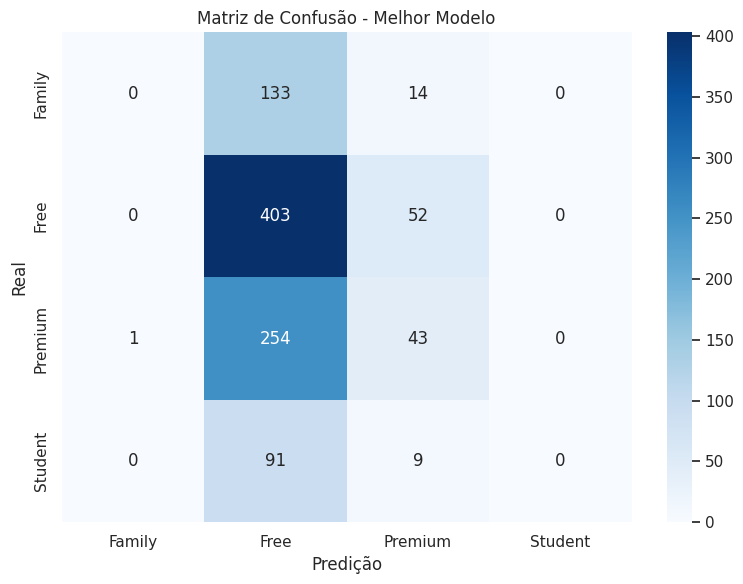

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

best_model = rf_model
y_pred_best = y_pred_rf

labels = sorted(y.unique())

cm = confusion_matrix(y_test, y_pred_best, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predição")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Melhor Modelo")
plt.tight_layout()
plt.show()

**Comentário:**  
O melhor modelo foi o que apresentou o maior equilíbrio entre acurácia e F1-score macro, além de manter desempenho razoável nas diferentes classes. Em geral, o `RandomForestClassifier` tende a ser uma boa escolha nesse tipo de problema porque modela relações não lineares e interações entre atributos com mais flexibilidade.

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

y_pred_final = y_pred_best

acc_final = accuracy_score(y_test, y_pred_final)
prec_final = precision_score(y_test, y_pred_final, average="macro", zero_division=0)
rec_final = recall_score(y_test, y_pred_final, average="macro", zero_division=0)
f1_final = f1_score(y_test, y_pred_final, average="macro", zero_division=0)

print(f"Acurácia:  {acc_final:.4f}")
print(f"Precisão:  {prec_final:.4f}")
print(f"Revocação: {rec_final:.4f}")
print(f"F1-score:  {f1_final:.4f}")

print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_final, zero_division=0))

Acurácia:  0.4460
Precisão:  0.2055
Revocação: 0.2575
F1-score:  0.2025

Relatório de classificação:
              precision    recall  f1-score   support

      Family       0.00      0.00      0.00       147
        Free       0.46      0.89      0.60       455
     Premium       0.36      0.14      0.21       298
     Student       0.00      0.00      0.00       100

    accuracy                           0.45      1000
   macro avg       0.21      0.26      0.20      1000
weighted avg       0.32      0.45      0.34      1000



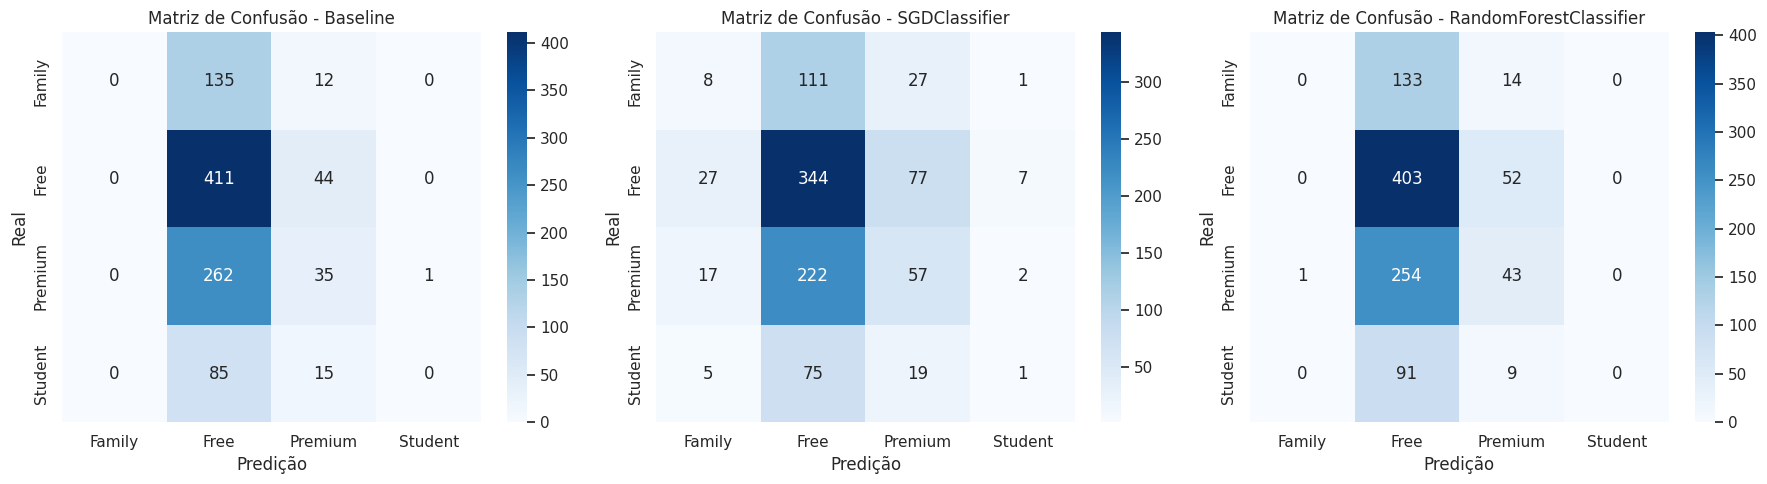

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels = sorted(y.unique())

preds = {
    "Baseline": y_pred_base,
    "SGDClassifier": y_pred_sgd,
    "RandomForestClassifier": y_pred_rf
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax
    )
    ax.set_title(f"Matriz de Confusão - {name}")
    ax.set_xlabel("Predição")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()

**Comentário**
É percepitivel por meio das matriz de confusão que os modelos classificaram a maioria dos usuario como Free

In [25]:
comparison = pd.DataFrame({
    "Modelo": ["Baseline", "SGDClassifier", "RandomForestClassifier"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_base),
        accuracy_score(y_test, y_pred_sgd),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision_macro": [
        precision_score(y_test, y_pred_base, average="macro", zero_division=0),
        precision_score(y_test, y_pred_sgd, average="macro", zero_division=0),
        precision_score(y_test, y_pred_rf, average="macro", zero_division=0)
    ],
    "Recall_macro": [
        recall_score(y_test, y_pred_base, average="macro", zero_division=0),
        recall_score(y_test, y_pred_sgd, average="macro", zero_division=0),
        recall_score(y_test, y_pred_rf, average="macro", zero_division=0)
    ],
    "F1_macro": [
        f1_score(y_test, y_pred_base, average="macro", zero_division=0),
        f1_score(y_test, y_pred_sgd, average="macro", zero_division=0),
        f1_score(y_test, y_pred_rf, average="macro", zero_division=0)
    ]
})

display(comparison.sort_values("F1_macro", ascending=False))

,Modelo,Accuracy,Precision_macro,Recall_macro,F1_macro
1,SGDClassifier,0.41,0.25,0.25,0.23
2,RandomForestClassifier,0.45,0.21,0.26,0.20
0,Baseline,0.45,0.20,0.26,0.20


### Discussão dos resultados

Os três modelos apresentaram acurácia em torno de 0,4, o que indica um desempenho apenas moderado na tarefa de classificação. Esse resultado sugere que os atributos disponíveis conseguem capturar parte do comportamento dos usuários, mas ainda não são suficientes para separar com alta precisão as classes de `subscription`.

Um fator que pode explicar esse desempenho é a sobreposição entre os perfis dos usuários. Em um dataset de hábitos de streaming, é comum que diferentes categorias de assinatura apresentem padrões parecidos em variáveis como tempo de escuta, número de músicas e taxa de skip, o que dificulta a discriminação entre as classes. Além disso, o uso de variáveis categóricas codificadas e atributos numéricos possivelmente não captura relações mais complexas que influenciam a assinatura.

Outro ponto é que a acurácia sozinha pode esconder diferenças relevantes entre as classes. Mesmo quando o valor global fica próximo de 0,4, o modelo pode estar acertando melhor algumas categorias do que outras, especialmente se houver desbalanceamento. Por isso, a matriz de confusão e as métricas como precisão, revocação e F1-score macro são essenciais para interpretar o comportamento real dos modelos.

Em resumo, o resultado evidencia como a escolha de dados e variaveis é de extrema importancia para o sucesso de uma atividade de Aprendizado de Máquina, como o dataset foi escolhido anteriomente e não poderia ser mudado acabou que o resultado não foi dos melhores, mas não deixando de passar tal aprendizado para atividades futuras